# DoC Post-Inhibition Fit

This notebook fits DoC curves after the inhibition period with:

```python
DoC = 1 - a * exp(-b * t_post)
```

`t_post = 0` is assigned in preprocessing, not fitted. The key diagnostic is therefore the detected inhibition-end time printed for every trace.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

DATA_ROOT = Path(r'.\circles_TEMPO_10,15,20,25mW_0,1,5mM')

# Detection settings are deliberately explicit. Change these first if onset looks wrong.
SETTLE_POINTS = 3          # minimum frames to skip at the beginning
SETTLE_LEVEL = 0.03        # ignore the first LED/camera jump up to this normalized level
SETTLE_AFTER_LEVEL = 2     # extra frames skipped after SETTLE_LEVEL is first reached
ONSET_DELTA = 0.005        # normalized signal above baseline required to call cure start
SUSTAIN_POINTS = 2         # require this many consecutive points above onset level
T30_LEVEL = 0.30
T90_LEVEL = 0.90

# Optional trusted inhibition-time inputs. If provided, these override auto detection.
# Use per-trace values for maximum control, or energy by TEMPO concentration when
# inhibition end is modeled as time = inhibition_energy / intensity.
KNOWN_INHIBITION_ENDS_S = {
    # '20mW_5_mM_TEMPO_T1': 4.67,
}
KNOWN_INHIBITION_ENERGY_MJ_CM2 = {
    # 5: 93.4,
}


def post_inhibition_func(t, a, b):
    return 1 - a * np.exp(-b * t)


def first_crossing_time(time, signal, level):
    idx = np.flatnonzero(signal >= level)
    return float(time[idx[0]]) if len(idx) else np.nan


def parse_metadata(csv_path):
    match = re.search(r'(\d+)mW\s+(\d+)mM\s+TEMPO', csv_path.parent.name)
    if not match:
        raise ValueError(f'Cannot parse intensity/TEMPO from {csv_path.parent}')
    return int(match.group(1)), int(match.group(2))


def detect_inhibition_end(time, signal_norm):
    """Return the first sustained rise above the inhibition plateau.

    The first frames often contain a camera/LED settling jump, so baseline is
    estimated after SETTLE_POINTS and before the raw 30% crossing. The 10th
    percentile is used so the early rising tail does not lift the baseline.
    """
    t30_idx = np.flatnonzero(signal_norm >= T30_LEVEL)
    stop = int(t30_idx[0]) if len(t30_idx) else len(signal_norm)

    # Some traces start near zero, then jump to a flat illumination baseline.
    # That settling jump is not cure onset, so baseline estimation begins after it.
    settled_idx = np.flatnonzero(signal_norm >= SETTLE_LEVEL)
    level_start = int(settled_idx[0]) + SETTLE_AFTER_LEVEL if len(settled_idx) else 0
    start = max(SETTLE_POINTS, level_start)
    start = min(start, max(0, len(signal_norm) - 1))

    stop = max(stop, start + 1)
    baseline_region = signal_norm[start:stop]
    baseline = float(np.percentile(baseline_region, 10))
    onset_level = baseline + ONSET_DELTA

    for i in range(start, len(signal_norm) - SUSTAIN_POINTS + 1):
        window = signal_norm[i:i + SUSTAIN_POINTS]
        if np.all(window >= onset_level):
            return i, float(time[i]), baseline, onset_level

    # Conservative fallback: use the raw 30% crossing if no onset is detected.
    fallback_idx = int(t30_idx[0]) if len(t30_idx) else start
    return fallback_idx, float(time[fallback_idx]), baseline, onset_level


def fit_trace(time, signal, known_onset_time=None):
    signal_norm = signal / np.nanmax(signal)
    auto_idx, auto_time, baseline, onset_level = detect_inhibition_end(time, signal_norm)
    if known_onset_time is None:
        onset_idx = auto_idx
        onset_time = auto_time
        onset_source = 'auto'
    else:
        onset_time = float(known_onset_time)
        onset_idx = int(np.searchsorted(time, onset_time, side='left'))
        onset_idx = min(onset_idx, len(time) - 1)
        onset_source = 'known'
    fit_time = time[onset_idx:] - onset_time
    fit_signal = signal_norm[onset_idx:]

    p0 = [max(1 - fit_signal[0], 0.1), 0.5]
    popt, pcov = curve_fit(
        post_inhibition_func,
        fit_time,
        fit_signal,
        p0=p0,
        bounds=([0.0, 0.0], [2.0, np.inf]),
        maxfev=10000,
    )
    a, b = map(float, popt)
    return {
        'a': a,
        'b': b,
        'onset_idx': onset_idx,
        'onset_time_s': onset_time,
        'onset_source': onset_source,
        'auto_onset_time_s': auto_time,
        'baseline_norm': baseline,
        'onset_level_norm': onset_level,
        'raw_t30_s': first_crossing_time(time, signal_norm, T30_LEVEL),
        'raw_t90_s': first_crossing_time(time, signal_norm, T90_LEVEL),
        'fit_t30_s': onset_time + np.log(a / (1 - T30_LEVEL)) / b,
        'fit_t90_s': onset_time + np.log(a / (1 - T90_LEVEL)) / b,
        'fit_time': fit_time,
        'fit_signal': fit_signal,
        'signal_norm': signal_norm,
    }


def known_inhibition_end(trace_id, intensity_mw, tempo_mm):
    if trace_id in KNOWN_INHIBITION_ENDS_S:
        return KNOWN_INHIBITION_ENDS_S[trace_id]
    if tempo_mm in KNOWN_INHIBITION_ENERGY_MJ_CM2:
        return KNOWN_INHIBITION_ENERGY_MJ_CM2[tempo_mm] / intensity_mw
    return None


def iter_traces(csv_path):
    df = pd.read_csv(csv_path)
    for time_col in df.columns:
        if not time_col.endswith('_Time_s'):
            continue
        signal_col = time_col.replace('_Time_s', '_Intensity')
        if signal_col not in df.columns:
            continue
        trace = df[[time_col, signal_col]].dropna()
        yield time_col.replace('_Time_s', ''), trace[time_col].to_numpy(), trace[signal_col].to_numpy()


In [2]:
rows = []
trace_cache = {}

for csv_path in sorted(DATA_ROOT.glob('*mM TEMPO/*mW*mM TEMPO/intensity_data.csv')):
    intensity_mw, tempo_mm = parse_metadata(csv_path)
    for trace_id, time, signal in iter_traces(csv_path):
        known_onset = known_inhibition_end(trace_id, intensity_mw, tempo_mm)
        fit = fit_trace(time, signal, known_onset_time=known_onset)
        rows.append({
            'tempo_mM': tempo_mm,
            'intensity_mW': intensity_mw,
            'trace_id': trace_id,
            'a': fit['a'],
            'b': fit['b'],
            'onset_time_s': fit['onset_time_s'],
            'onset_source': fit['onset_source'],
            'auto_onset_time_s': fit['auto_onset_time_s'],
            'baseline_norm': fit['baseline_norm'],
            'onset_level_norm': fit['onset_level_norm'],
            'raw_t30_s': fit['raw_t30_s'],
            'raw_t90_s': fit['raw_t90_s'],
            'fit_t30_s': fit['fit_t30_s'],
            'fit_t90_s': fit['fit_t90_s'],
        })
        trace_cache[trace_id] = (time, signal, fit)

results = pd.DataFrame(rows).sort_values(['tempo_mM', 'intensity_mW', 'trace_id'])
summary = results.groupby(['tempo_mM', 'intensity_mW'], as_index=False).agg(
    a_mean=('a', 'mean'),
    a_std=('a', 'std'),
    b_mean=('b', 'mean'),
    b_std=('b', 'std'),
    onset_mean_s=('onset_time_s', 'mean'),
    raw_t30_mean_s=('raw_t30_s', 'mean'),
    raw_t90_mean_s=('raw_t90_s', 'mean'),
    fit_t30_mean_s=('fit_t30_s', 'mean'),
    fit_t90_mean_s=('fit_t90_s', 'mean'),
)

print('Per-trace post-inhibition fits')
display(results.round(4))
print('Grouped mean fits')
display(summary.round(4))


Per-trace post-inhibition fits


,tempo_mM,intensity_mW,trace_id,a,b,onset_time_s,onset_source,auto_onset_time_s,baseline_norm,onset_level_norm,raw_t30_s,raw_t90_s,fit_t30_s,fit_t90_s
0,0,10,10mW_0_mM_TEMPO_T1,0.9632,0.5343,1.4099,auto,1.4099,0.0896,0.0946,2.2156,5.8412,2.0074,5.6496
1,0,10,10mW_0_mM_TEMPO_T2,0.9729,0.5399,1.4100,auto,1.4100,0.0900,0.0950,2.2157,5.8415,2.0198,5.6240
2,0,15,15mW_0_mM_TEMPO_T1,0.9853,0.6599,1.0071,auto,1.0071,0.0846,0.0896,1.8128,4.6327,1.5251,4.4737
3,0,15,15mW_0_mM_TEMPO_T2,0.9948,0.6686,1.0072,auto,1.0072,0.0876,0.0926,1.8129,4.4315,1.5328,4.4433
4,0,20,20mW_0_mM_TEMPO_T1,1.0035,0.7796,0.8057,auto,0.8057,0.0873,0.0923,1.4100,3.8271,1.2677,3.7638
5,0,20,20mW_0_mM_TEMPO_T2,0.9990,0.8065,0.8057,auto,0.8057,0.0885,0.0935,1.4100,3.6258,1.2467,3.6597
6,0,25,25mW_0_mM_TEMPO_T1,0.9477,0.9791,0.8057,auto,0.8057,0.0888,0.0938,1.2085,3.2227,1.1152,3.1027
7,0,25,25mW_0_mM_TEMPO_T2,0.9600,0.9462,0.8057,auto,0.8057,0.0923,0.0973,1.4100,3.2228,1.1396,3.1961
8,1,10,10mW_1_mM_TEMPO_T1,1.0254,0.6051,2.8200,auto,2.8200,0.0711,0.0761,3.8272,7.0500,3.4509,6.6667
9,1,10,10mW_1_mM_TEMPO_T2,0.9872,0.4848,2.8200,auto,2.8200,0.0882,0.0932,3.8271,7.8556,3.5291,7.5426


Grouped mean fits


,tempo_mM,intensity_mW,a_mean,a_std,b_mean,b_std,onset_mean_s,raw_t30_mean_s,raw_t90_mean_s,fit_t30_mean_s,fit_t90_mean_s
0,0,10,0.9681,0.0068,0.5371,0.0040,1.4100,2.2157,5.8414,2.0136,5.6368
1,0,15,0.9900,0.0067,0.6643,0.0061,1.0071,1.8129,4.5321,1.5289,4.4585
2,0,20,1.0013,0.0032,0.7930,0.0190,0.8057,1.4100,3.7264,1.2572,3.7117
3,0,25,0.9539,0.0087,0.9626,0.0232,0.8057,1.3092,3.2228,1.1274,3.1494
4,1,10,1.0063,0.0270,0.5450,0.0850,2.8200,3.8271,7.4528,3.4900,7.1047
5,1,15,0.9664,0.0315,0.6268,0.0101,2.7193,3.4243,6.5465,3.2340,6.3391
6,1,20,0.9722,0.0046,0.8074,0.0098,1.6115,2.2158,4.5323,2.0183,4.4285
7,1,25,1.0155,0.0051,0.8809,0.0203,1.2086,1.8129,3.8272,1.6311,3.8407
8,5,10,0.9622,0.0131,0.4713,0.0031,8.6615,9.5679,13.8987,9.3363,13.4651
9,5,15,0.9554,0.0006,0.6246,0.0006,5.8413,6.6470,9.6684,6.3393,9.4548


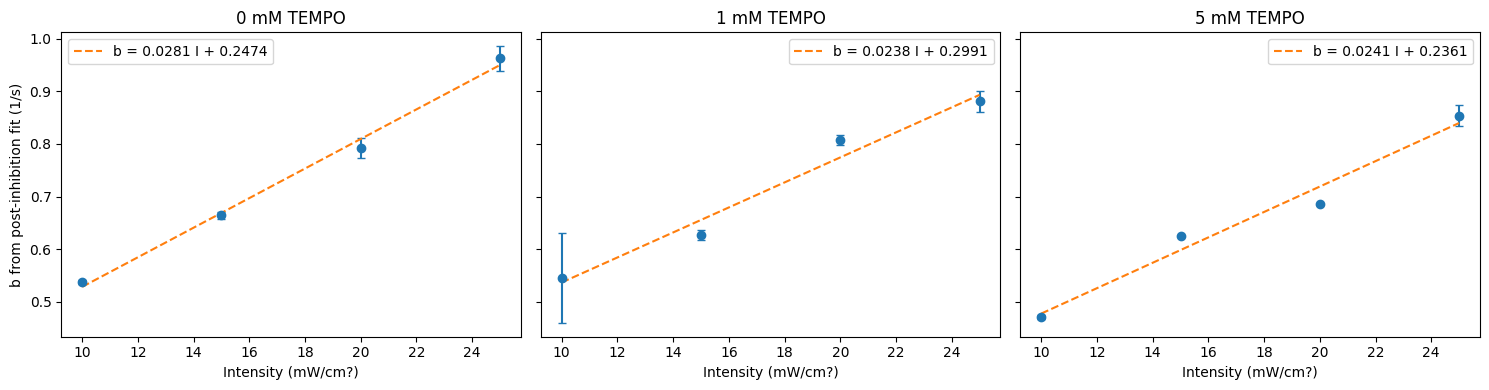

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tempo_mm in zip(axes, sorted(summary['tempo_mM'].unique())):
    data = summary[summary['tempo_mM'] == tempo_mm]
    slope, intercept = np.polyfit(data['intensity_mW'], data['b_mean'], 1)
    x = np.linspace(data['intensity_mW'].min(), data['intensity_mW'].max(), 100)
    ax.errorbar(data['intensity_mW'], data['b_mean'], yerr=data['b_std'], fmt='o', capsize=3)
    ax.plot(x, slope * x + intercept, '--', label=f'b = {slope:.4f} I + {intercept:.4f}')
    ax.set_title(f'{tempo_mm} mM TEMPO')
    ax.set_xlabel('Intensity (mW/cm?)')
    ax.legend()
axes[0].set_ylabel('b from post-inhibition fit (1/s)')
fig.tight_layout()
plt.show()


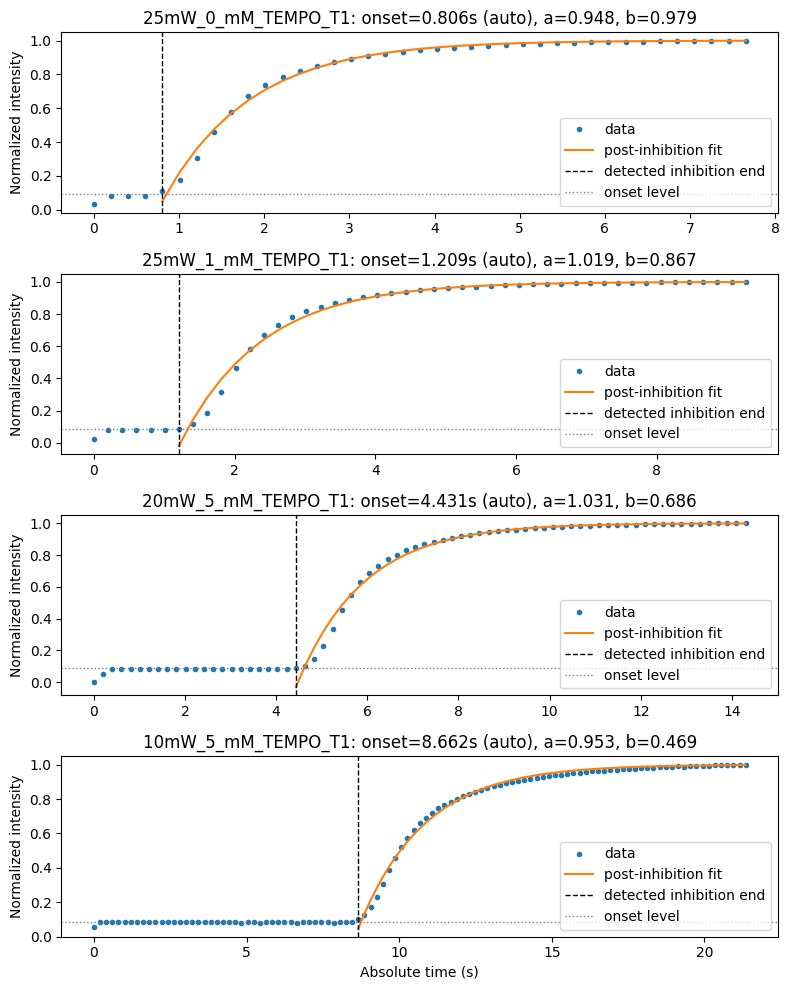

In [4]:
# Plot representative traces with detected inhibition end.
example_ids = [
    '25mW_0_mM_TEMPO_T1',
    '25mW_1_mM_TEMPO_T1',
    '20mW_5_mM_TEMPO_T1',
    '10mW_5_mM_TEMPO_T1',
]

fig, axes = plt.subplots(len(example_ids), 1, figsize=(8, 10), sharex=False)
for ax, trace_id in zip(axes, example_ids):
    time, signal, fit = trace_cache[trace_id]
    y = fit['signal_norm']
    onset_time = fit['onset_time_s']
    fitted = post_inhibition_func(fit['fit_time'], fit['a'], fit['b'])

    ax.plot(time, y, 'o', ms=3, label='data')
    ax.plot(time[fit['onset_idx']:], fitted, '-', label='post-inhibition fit')
    ax.axvline(onset_time, color='k', ls='--', lw=1, label='detected inhibition end')
    ax.axhline(fit['onset_level_norm'], color='gray', ls=':', lw=1, label='onset level')
    ax.set_title(
        f"{trace_id}: onset={onset_time:.3f}s ({fit['onset_source']}), a={fit['a']:.3f}, b={fit['b']:.3f}"
    )
    ax.set_ylabel('Normalized intensity')
    ax.legend(loc='lower right')
axes[-1].set_xlabel('Absolute time (s)')
fig.tight_layout()
plt.show()
